# Minimal Hippocampal Theta Matrix

This notebook loads the signal matrix `X`, builds row-aligned train/test splits, fits fold-wise train-only decompositions, measures periodic bycycle features, trains a simple balanced logistic classifier, and plots a compact diagnostic figure.

The periodic signal uses `quadrature_phase`: a deterministic Fourier transfer derived only from the raw eigenspectrum and smooth AR fit. It exactly reconstructs the input, gives the aperiodic signal the fitted PSD, and preserves raw phase for the periodic residual at every frequency where raw power exceeds the fit. It uses no balance band, pivot, signs, labels, or dataset-specific phase settings.

The classifier remains a simple logistic regression. It uses six direct timing, symmetry, and cycle-quality features after subtracting each session/channel's label-blind training mean, and raw and periodic models are evaluated on exactly matched rows.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from joblib import Parallel, delayed, dump, load, parallel_config
from sklearn.model_selection import StratifiedGroupKFold

from eigvec.experiments import (
    dandi_000059_candidate_sessions,
    load_crcns_condition_matrices,
    load_or_build_dandi_downsampled_lfp_cache,
    standardize_rows,
)

ROOT = Path.cwd()
if not (ROOT / "notebooks").exists():
    ROOT = ROOT.parent

SHEET_PATH = ROOT / "Medial Septal Cooling project - Public - Ephys sessions.csv"
PROCESSED_ROOT = ROOT / "notebooks/data/dandi/000059/0.250624.0444"
DANDI_ASSET_MANIFEST = ROOT / "notebooks/data/dandi/000059/assets_0.250624.0444.json"
DANDI_DOWNSAMPLED_DIR = ROOT / "notebooks/data/dandi/000059/downsampled_lfp"
DANDI_DOWNSAMPLED_H5 = DANDI_DOWNSAMPLED_DIR / "dandi_000059_theta_trials_1250hz.h5"
DANDI_DOWNSAMPLED_TRIALS = DANDI_DOWNSAMPLED_DIR / "dandi_000059_theta_trials_1250hz.csv"
DANDI_RAW_TMP = ROOT / "notebooks/data/dandi/000059/raw_tmp"
PERIODIC_MODE = "quadrature_phase"
FEATURE_PIPELINE_VERSION = "within_channel_timing_v2_phase_transfer"
TRAINING_CACHE_PATH = (
    ROOT / "notebooks/data/cache"
    / f"15_hippocampal_theta_cv_{PERIODIC_MODE}_{FEATURE_PIPELINE_VERSION}.joblib"
)

FS = 1250.0
WINDOW_SECONDS = 2.0
WINDOW_STEP_SECONDS = WINDOW_SECONDS
CONDITIONS = {"control": "Pre-Cooling", "cooling": "Cooling on"}
POSITIVE_CONDITION = "cooling"

STANDARDIZE_X = True
DOWNLOAD_DANDI_RAW = False
DANDI_REBUILD_DOWNSAMPLED = False
DANDI_RAW_MAX_ASSETS = 32
DANDI_RAW_MAX_TOTAL_GB = 600.0
DANDI_DELETE_RAW_AFTER_DOWNSAMPLE = True
DANDI_MIN_TRIALS = 100

RUN_TRAINING = True
TRAINING_N_JOBS = 10

CV_SPLITS = 5
CV_GROUP_COLUMN = "trial_group"
CV_RANDOM_STATE = 123

In [2]:
dandi_candidates = dandi_000059_candidate_sessions(
    DANDI_ASSET_MANIFEST,
    SHEET_PATH,
    min_trials=DANDI_MIN_TRIALS,
)

dandi_trial_index = load_or_build_dandi_downsampled_lfp_cache(
    dandi_candidates,
    DANDI_DOWNSAMPLED_H5,
    DANDI_DOWNSAMPLED_TRIALS,
    PROCESSED_ROOT,
    DANDI_RAW_TMP,
    target_fs=FS,
    max_assets=DANDI_RAW_MAX_ASSETS,
    max_total_gb=DANDI_RAW_MAX_TOTAL_GB,
    download_missing=DOWNLOAD_DANDI_RAW,
    rebuild=DANDI_REBUILD_DOWNSAMPLED,
    delete_raw_after_downsample=DANDI_DELETE_RAW_AFTER_DOWNSAMPLE,
)
if dandi_trial_index.empty:
    raise RuntimeError("No DANDI downsampled LFP cache is available.")

matrices = load_crcns_condition_matrices(
    DANDI_DOWNSAMPLED_H5,
    dandi_trial_index,
    conditions=CONDITIONS,
    window_seconds=WINDOW_SECONDS,
    step_seconds=WINDOW_STEP_SECONDS,
    fs=FS,
    manipulation="Cooling",
    arena_contains="Theta maze",
)

X_parts = []
label_parts = []
row_start = 0
for condition, matrix in matrices.items():
    X_condition = matrix.X.astype(np.float32, copy=False)
    if STANDARDIZE_X:
        X_condition = standardize_rows(X_condition)

    n_rows = X_condition.shape[0]
    labels = matrix.rows.copy().reset_index(drop=True)
    labels.insert(0, "row", np.arange(row_start, row_start + n_rows, dtype=int))
    labels.insert(1, "condition", condition)
    labels.insert(2, "y", int(condition == POSITIVE_CONDITION))
    labels.insert(3, "condition_matrix_row", np.arange(n_rows, dtype=int))
    X_parts.append(X_condition)
    label_parts.append(labels)
    row_start += n_rows

X = np.vstack(X_parts).astype(np.float32, copy=False)
split_labels = pd.concat(label_parts, ignore_index=True)
split_labels["trial_group"] = (
    split_labels["session"].astype(str)
    + "::trial_"
    + split_labels["trial_id"].astype(str)
)
if not np.array_equal(split_labels["row"].to_numpy(), np.arange(X.shape[0])):
    raise RuntimeError("split_labels rows are not aligned to X.")

In [3]:
groups_per_class = split_labels.groupby("condition")[CV_GROUP_COLUMN].nunique()
n_splits = int(min(CV_SPLITS, groups_per_class.min()))
if n_splits < 2:
    raise RuntimeError(f"Need at least two {CV_GROUP_COLUMN!r} groups per condition; got {groups_per_class.to_dict()}.")

y = split_labels["y"].to_numpy()
cv_groups = split_labels[CV_GROUP_COLUMN].astype(str).to_numpy()
splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=CV_RANDOM_STATE)

split_indices = {}
for fold, (train_index, test_index) in enumerate(splitter.split(np.zeros((len(split_labels), 1)), y, groups=cv_groups)):
    column = f"fold_{fold}"
    split_labels[column] = "train"
    split_labels.loc[test_index, column] = "test"
    split_indices[column] = {"train": train_index, "test": test_index}

split_columns = [f"fold_{fold}" for fold in range(n_splits)]
if not split_labels[split_columns].isin(["train", "test"]).all().all():
    raise RuntimeError("Every fold column should contain only 'train' or 'test'.")

In [4]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.signal import filtfilt, iirnotch, welch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from eigvec.core import OscEig
from eigvec.experiments import RobustAperiodicAR, SignalMatrix
from eigvec.experiments.bycycle import measure_bycycle_features

THETA_BAND = (6.0, 11.0)
LOW_BAND = (1.0, 15.0)
THETA_KEEP_QUANTILE = 0.01

AR_ORDER = 80
AR_FIT_MIN_FREQ = 1e-9
AR_FIT_MAX_FREQ = 550.0
AR_LOSS_FN = "linear"
AR_F_SCALE = None
AR_MAXFEV = 10_000

AR_ASYMMETRIC_OVERFIT_PENALTY = True
AR_OVERFIT_WEIGHT = 0.0
AR_LOW_FREQ_OVERFIT_WEIGHT = 0.0
AR_LOW_FREQ_RESIDUAL_WEIGHT = 500.0
AR_LOW_FREQ_MAX = 3.0

AR_LOGLOG_SLOPE_CHANGE_WEIGHT = 1.0
AR_POSITIVE_LOGLOG_SLOPE_WEIGHT = 100.0
AR_POSITIVE_LOGLOG_SLOPE_TOLERANCE = 0.0
AR_SLOPE_PENALTY_GRID_SIZE = 256

C = 1.0
LINE_FREQ = 60.0
LINE_NOTCH_Q = 30.0

CLASSIFIER_FEATURE_COLUMNS = [
    "band_amp",
    "monotonicity",
    "period_ms",
    "time_rdsym",
    "time_ptsym",
    "volt_rise",
    "volt_decay",
    "amp_fraction",
    "amp_consistency",
    "period_consistency",
]
PRIMARY_FEATURE_COLUMNS = [
    "period_ms",
    "monotonicity",
    "time_rdsym",
    "time_ptsym",
    "amp_consistency",
    "period_consistency",
]
CENTER_GROUP_COLUMNS = ["session", "raw_channel"]


def notch_rows(X, fs, line_freq=LINE_FREQ, q=LINE_NOTCH_Q):
    if line_freq <= 0 or line_freq >= fs / 2:
        return X.copy()
    b, a = iirnotch(line_freq, q, fs=fs)
    return filtfilt(b, a, X, axis=1)


def theta_power_fraction(X, fs):
    freqs, powers = welch(X, fs=fs, nperseg=min(int(fs), X.shape[1]), axis=1)
    theta_mask = (freqs >= THETA_BAND[0]) & (freqs <= THETA_BAND[1])
    low_mask = (freqs >= LOW_BAND[0]) & (freqs <= LOW_BAND[1])
    return powers[:, theta_mask].sum(axis=1) / np.maximum(powers[:, low_mask].sum(axis=1), 1e-12)

theta_fraction = theta_power_fraction(X, FS)
keep = theta_fraction >= np.quantile(theta_fraction, THETA_KEEP_QUANTILE)
print(f"Keeping {keep.sum()} / {len(keep)} rows after theta-power QC")

X_qc = X[keep]
split_labels_qc = split_labels.loc[keep].reset_index(drop=True)
display(split_labels_qc.groupby("condition").size().rename("rows").reset_index())


Keeping 12985 / 13117 rows after theta-power QC


,condition,rows
0,control,5365
1,cooling,7620


In [5]:
BYCYCLE_BAND = (5, 15)
BYCYCLE_THRESHOLDS = {
    "amp_fraction": 0.2,
    "amp_consistency": 0.2,
    "period_consistency": 0.2,
    "monotonicity": 0.2,
}
BYCYCLE_BURST_ONLY = True
BYCYCLE_MIN_CYCLES_PER_ROW = 5
BYCYCLE_PROVENANCE_COLUMNS = [
    "row",
    "condition_matrix_row",
    "animal",
    "session",
    "trial_id",
    "trial_group",
    "window_start_s",
    "raw_channel",
]

RESULT_TABLES = (
    "bycycle_features",
    "cooling_row_features",
    "classifier_scores",
    "classifier_predictions",
    "classifier_coefficients",
)


def _training_configuration():
    return {
        "periodic_mode": PERIODIC_MODE,
        "feature_pipeline_version": FEATURE_PIPELINE_VERSION,
        "fs": FS,
        "window_seconds": WINDOW_SECONDS,
        "ar_order": AR_ORDER,
        "ar_fit_min_freq": AR_FIT_MIN_FREQ,
        "ar_fit_max_freq": AR_FIT_MAX_FREQ,
        "ar_loss_fn": AR_LOSS_FN,
        "ar_f_scale": AR_F_SCALE,
        "ar_maxfev": AR_MAXFEV,
        "ar_asymmetric_overfit_penalty": AR_ASYMMETRIC_OVERFIT_PENALTY,
        "ar_overfit_weight": AR_OVERFIT_WEIGHT,
        "ar_low_freq_overfit_weight": AR_LOW_FREQ_OVERFIT_WEIGHT,
        "ar_low_freq_residual_weight": AR_LOW_FREQ_RESIDUAL_WEIGHT,
        "ar_low_freq_max": AR_LOW_FREQ_MAX,
        "ar_loglog_slope_change_weight": AR_LOGLOG_SLOPE_CHANGE_WEIGHT,
        "ar_positive_loglog_slope_weight": AR_POSITIVE_LOGLOG_SLOPE_WEIGHT,
        "ar_positive_loglog_slope_tolerance": AR_POSITIVE_LOGLOG_SLOPE_TOLERANCE,
        "ar_slope_penalty_grid_size": AR_SLOPE_PENALTY_GRID_SIZE,
        "bycycle_band": BYCYCLE_BAND,
        "bycycle_thresholds": BYCYCLE_THRESHOLDS,
        "bycycle_burst_only": BYCYCLE_BURST_ONLY,
        "bycycle_min_cycles_per_row": BYCYCLE_MIN_CYCLES_PER_ROW,
        "primary_feature_columns": PRIMARY_FEATURE_COLUMNS,
        "logistic_c": C,
    }


def _concat_result_tables(results):
    return {
        name: pd.concat([result[name] for result in results], ignore_index=True)
        for name in RESULT_TABLES
    }


def _condition_matrices(X_part, rows_part):
    matrices = {}
    for condition in CONDITIONS:
        condition_keep = rows_part["condition"].eq(condition).to_numpy()
        if condition_keep.any():
            matrices[condition] = SignalMatrix(
                X_part[condition_keep],
                rows_part.loc[condition_keep].reset_index(drop=True),
                FS,
                condition,
            )
    return matrices


def _measure_rows(matrices, component, fold, split):
    rows = pd.concat([matrix.rows for matrix in matrices.values()], ignore_index=True)
    provenance_columns = [column for column in BYCYCLE_PROVENANCE_COLUMNS if column in rows.columns]
    cycles = measure_bycycle_features(
        matrices,
        BYCYCLE_BAND,
        component=component,
        thresholds=BYCYCLE_THRESHOLDS,
        provenance_columns=provenance_columns,
        burst_only=BYCYCLE_BURST_ONLY,
        min_cycles_per_row=BYCYCLE_MIN_CYCLES_PER_ROW,
    )
    if not cycles.empty:
        cycles = cycles.copy()
        cycles.insert(0, "fold", fold)
        cycles.insert(1, "split", split)
    return cycles


def _row_features(cycles, component, fold, split):
    if cycles.empty:
        return pd.DataFrame(columns=["fold", "split", "component", "row", "condition", "y", *CENTER_GROUP_COLUMNS, *CLASSIFIER_FEATURE_COLUMNS])
    available = [feature for feature in CLASSIFIER_FEATURE_COLUMNS if feature in cycles.columns]
    metadata_columns = [
        column for column in BYCYCLE_PROVENANCE_COLUMNS
        if column not in {"row"} and column in cycles.columns
    ]
    features = (
        cycles.groupby(["row", "condition"], as_index=False)[available]
        .median(numeric_only=True)
        .replace([np.inf, -np.inf], np.nan)
    )
    metadata = (
        cycles.groupby(["row", "condition"], as_index=False)[metadata_columns]
        .first()
    )
    features = features.merge(metadata, on=["row", "condition"], how="left", validate="one_to_one")
    required = [feature for feature in PRIMARY_FEATURE_COLUMNS if feature in features.columns]
    features = features.dropna(subset=required)
    features.insert(0, "fold", fold)
    features.insert(1, "split", split)
    features.insert(2, "component", component)
    features["y"] = features["condition"].map({"control": 0, "cooling": 1}).astype(int)
    return features


def _center_on_training_group(train_rows, test_rows, feature_columns):
    baseline_columns = {feature: f"__baseline_{feature}" for feature in feature_columns}
    baselines = (
        train_rows.groupby(CENTER_GROUP_COLUMNS, as_index=False)[feature_columns]
        .mean()
        .rename(columns=baseline_columns)
    )

    def transform(rows):
        centered = rows.merge(
            baselines, on=CENTER_GROUP_COLUMNS, how="left", validate="many_to_one"
        )
        missing = centered[list(baseline_columns.values())].isna().any(axis=1)
        if missing.any():
            missing_groups = centered.loc[missing, CENTER_GROUP_COLUMNS].drop_duplicates()
            raise RuntimeError(
                "Every classified session/channel needs a label-blind training baseline; "
                f"missing {missing_groups.to_dict(orient='records')[:5]}"
            )
        for feature, baseline in baseline_columns.items():
            centered[feature] = centered[feature] - centered[baseline]
        return centered.drop(columns=list(baseline_columns.values()))

    return transform(train_rows), transform(test_rows)


def _fit_logistic(component, fold, train_rows, test_rows):
    feature_columns = [
        feature for feature in PRIMARY_FEATURE_COLUMNS
        if feature in train_rows.columns and feature in test_rows.columns
    ]
    train_rows = train_rows.replace([np.inf, -np.inf], np.nan).dropna(subset=feature_columns)
    test_rows = test_rows.replace([np.inf, -np.inf], np.nan).dropna(subset=feature_columns)

    if len(feature_columns) == 0 or train_rows["y"].nunique() < 2 or test_rows["y"].nunique() < 2:
        print(f"  {component}: skipped classifier")
        return {
            "classifier_scores": pd.DataFrame(),
            "classifier_predictions": pd.DataFrame(),
            "classifier_coefficients": pd.DataFrame(),
        }

    train_groups = set(train_rows["trial_group"].astype(str))
    test_groups = set(test_rows["trial_group"].astype(str))
    if not train_groups.isdisjoint(test_groups):
        raise RuntimeError(f"{fold}: train/test trial groups overlap")
    train_rows, test_rows = _center_on_training_group(
        train_rows, test_rows, feature_columns
    )

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight="balanced", C=C, random_state=0),
    )
    clf.fit(train_rows[feature_columns], train_rows["y"])

    class_index = np.flatnonzero(clf.named_steps["logisticregression"].classes_ == 1)[0]
    y_score = clf.predict_proba(test_rows[feature_columns])[:, class_index]
    y_pred = clf.predict(test_rows[feature_columns])
    fold_auc = roc_auc_score(test_rows["y"], y_score)
    fold_bal_acc = balanced_accuracy_score(test_rows["y"], y_pred)

    scores = pd.DataFrame([{
        "fold": fold,
        "component": component,
        "train_rows": len(train_rows),
        "test_rows": len(test_rows),
        "test_control": int((test_rows["y"] == 0).sum()),
        "test_cooling": int((test_rows["y"] == 1).sum()),
        "feature_set": FEATURE_PIPELINE_VERSION,
        "baseline": "label_blind_training_session_x_channel_mean",
        "auc": fold_auc,
        "balanced_accuracy": fold_bal_acc,
    }])
    predictions = pd.DataFrame(
        {
            "fold": fold,
            "component": component,
            "row": row_id,
            "condition": condition,
            "trial_group": trial_group,
            "y_true": int(y_true),
            "y_score": float(score),
            "y_pred": int(pred),
        }
        for row_id, condition, trial_group, y_true, score, pred in zip(
            test_rows["row"], test_rows["condition"], test_rows["trial_group"],
            test_rows["y"], y_score, y_pred
        )
    )
    coefficients = pd.DataFrame({
        "fold": fold,
        "component": component,
        "feature": feature_columns,
        "standardized_logistic_coef": clf.named_steps["logisticregression"].coef_[0],
    })
    print(f"  {component}: AUC={fold_auc:.3f}, balanced accuracy={fold_bal_acc:.3f}, rows used={len(test_rows)}")
    return {
        "classifier_scores": scores,
        "classifier_predictions": predictions,
        "classifier_coefficients": coefficients,
    }


def _run_fold(fold, X, split_labels, keep):
    component_results = []

    train_keep = keep & split_labels[fold].eq("train").to_numpy()
    test_keep = keep & split_labels[fold].eq("test").to_numpy()

    X_train = X[train_keep]
    X_test = X[test_keep]
    y_train = split_labels.loc[train_keep, "y"].to_numpy()
    y_test = split_labels.loc[test_keep, "y"].to_numpy()
    rows_train = split_labels.loc[train_keep].reset_index(drop=True)
    rows_test = split_labels.loc[test_keep].reset_index(drop=True)

    print(
        fold,
        len(X_train),
        len(X_test),
        round(len(X_test) / len(X_train), 3),
        np.bincount(y_train),
        np.bincount(y_test),
    )

    psd_model = RobustAperiodicAR(
        fs=FS,
        order=AR_ORDER,
        fit_min_freq=AR_FIT_MIN_FREQ,
        fit_max_freq=AR_FIT_MAX_FREQ,
        loss_fn=AR_LOSS_FN,
        f_scale=AR_F_SCALE,
        maxfev=AR_MAXFEV,
        asymmetric_overfit_penalty=AR_ASYMMETRIC_OVERFIT_PENALTY,
        overfit_weight=AR_OVERFIT_WEIGHT,
        low_freq_residual_weight=AR_LOW_FREQ_RESIDUAL_WEIGHT,
        low_freq_overfit_weight=AR_LOW_FREQ_OVERFIT_WEIGHT,
        low_freq_max=AR_LOW_FREQ_MAX,
        loglog_slope_change_weight=AR_LOGLOG_SLOPE_CHANGE_WEIGHT,
        positive_loglog_slope_weight=AR_POSITIVE_LOGLOG_SLOPE_WEIGHT,
        positive_loglog_slope_tolerance=AR_POSITIVE_LOGLOG_SLOPE_TOLERANCE,
        slope_penalty_grid_size=AR_SLOPE_PENALTY_GRID_SIZE,
    )
    osc = OscEig(
        fs=FS,
        psd_model=psd_model,
        periodic_mode=PERIODIC_MODE,
    )
    osc.fit(X_train)

    X_train_periodic = osc.X_periodic_ if hasattr(osc, "X_periodic_") else osc.X_noncirc_
    X_test_aperiodic, X_test_periodic = osc.decompose(X_test)

    X_train_raw_notched = notch_rows(X_train, FS)
    X_test_raw_notched = notch_rows(X_test, FS)
    X_train_periodic_notched = notch_rows(X_train_periodic, FS)
    X_test_periodic_notched = notch_rows(X_test_periodic, FS)

    components = {
        "raw": (_condition_matrices(X_train_raw_notched, rows_train), _condition_matrices(X_test_raw_notched, rows_test)),
        "periodic": (_condition_matrices(X_train_periodic_notched, rows_train), _condition_matrices(X_test_periodic_notched, rows_test)),
    }

    component_tables = {}
    for component, (train_matrices, test_matrices) in components.items():
        train_cycles = _measure_rows(train_matrices, component, fold, "train")
        test_cycles = _measure_rows(test_matrices, component, fold, "test")
        train_rows_features = _row_features(train_cycles, component, fold, "train")
        test_rows_features = _row_features(test_cycles, component, fold, "test")
        component_tables[component] = {
            "train_cycles": train_cycles,
            "test_cycles": test_cycles,
            "train_rows": train_rows_features,
            "test_rows": test_rows_features,
        }

    matched_train_rows = set.intersection(
        *(set(tables["train_rows"]["row"]) for tables in component_tables.values())
    )
    matched_test_rows = set.intersection(
        *(set(tables["test_rows"]["row"]) for tables in component_tables.values())
    )
    if not matched_train_rows or not matched_test_rows:
        raise RuntimeError(f"{fold}: no matched raw/periodic rows for classification")

    for component, tables in component_tables.items():
        train_rows_features = tables["train_rows"].loc[
            tables["train_rows"]["row"].isin(matched_train_rows)
        ].copy()
        test_rows_features = tables["test_rows"].loc[
            tables["test_rows"]["row"].isin(matched_test_rows)
        ].copy()
        component_results.append({
            "bycycle_features": pd.concat(
                [tables["train_cycles"], tables["test_cycles"]], ignore_index=True
            ),
            "cooling_row_features": pd.concat([train_rows_features, test_rows_features], ignore_index=True),
            **_fit_logistic(component, fold, train_rows_features, test_rows_features),
        })

    decomposition = {
        "rows_test": rows_test,
        "X_test": X_test,
        "X_aperiodic": X_test_aperiodic,
        "X_periodic": X_test_periodic,
        "freqs_pos": osc.freqs_pos_.copy(),
        "powers_pos": osc.powers_pos_.copy(),
        "powers_fit_pos": osc.powers_fit_pos_.copy(),
        "periodic_mode": osc.periodic_mode,
        "periodic_phase_rule": "raw_phase_on_positive_amplitude_excess",
    }

    fit_ratio = osc.powers_pos_ / np.maximum(osc.powers_fit_pos_, 1e-12)
    theta_mask = (osc.freqs_pos_ >= THETA_BAND[0]) & (osc.freqs_pos_ <= THETA_BAND[1])
    theta_peak = osc.freqs_pos_[theta_mask][np.argmax(fit_ratio[theta_mask])]
    print(f"  theta peak over fit: {theta_peak:.2f} Hz")

    return {
        **_concat_result_tables(component_results),
        "fold": fold,
        "decomposition": decomposition,
    }


if RUN_TRAINING:
    with parallel_config(backend="loky", inner_max_num_threads=1):
        fold_results = Parallel(n_jobs=TRAINING_N_JOBS, verbose=10)(
            delayed(_run_fold)(fold, X, split_labels, keep)
            for fold in split_columns
        )
    training_results = {
        **_concat_result_tables(fold_results),
        "fold_decompositions": {result["fold"]: result["decomposition"] for result in fold_results},
        "configuration": _training_configuration(),
    }
    del fold_results
    TRAINING_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    dump(training_results, TRAINING_CACHE_PATH, compress=3)
    print(f"Cached training results at {TRAINING_CACHE_PATH}")
else:
    if not TRAINING_CACHE_PATH.exists():
        raise FileNotFoundError(
            f"Training cache not found at {TRAINING_CACHE_PATH}. Set RUN_TRAINING=True first."
        )
    training_results = load(TRAINING_CACHE_PATH)
    expected_configuration = _training_configuration()
    if training_results.get("configuration") != expected_configuration:
        raise RuntimeError(
            "Training cache configuration does not match this notebook; "
            "set RUN_TRAINING=True to rebuild it."
        )
    print(f"Loaded cached training results from {TRAINING_CACHE_PATH}")


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.


fold_1 10630 2355 0.222 [4401 6229] [ 964 1391]
fold_0 10267 2718 0.265 [4209 6058] [1156 1562]
fold_3 10137 2848 0.281 [4275 5862] [1090 1758]
fold_4 10487 2498 0.238 [4305 6182] [1060 1438]
fold_2 10419 2566 0.246 [4270 6149] [1095 1471]
  raw: AUC=0.823, balanced accuracy=0.743, rows used=2482
  periodic: AUC=0.936, balanced accuracy=0.869, rows used=2482
  theta peak over fit: 8.00 Hz
  raw: AUC=0.805, balanced accuracy=0.760, rows used=2829
  periodic: AUC=0.912, balanced accuracy=0.845, rows used=2829
  theta peak over fit: 8.00 Hz
  raw: AUC=0.835, balanced accuracy=0.763, rows used=2552
  periodic: AUC=0.945, balanced accuracy=0.878, rows used=2552
  theta peak over fit: 8.50 Hz
  raw: AUC=0.834, balanced accuracy=0.770, rows used=2345
  periodic: AUC=0.925, balanced accuracy=0.873, rows used=2345
  theta peak over fit: 8.00 Hz


[Parallel(n_jobs=10)]: Done   2 out of   5 | elapsed:  2.7min remaining:  4.1min


  raw: AUC=0.808, balanced accuracy=0.740, rows used=2703
  periodic: AUC=0.928, balanced accuracy=0.852, rows used=2703
  theta peak over fit: 8.00 Hz


[Parallel(n_jobs=10)]: Done   3 out of   5 | elapsed:  2.7min remaining:  1.8min
[Parallel(n_jobs=10)]: Done   5 out of   5 | elapsed:  2.7min finished


Cached training results at /home/rph/oscillatory_eigenvectors/notebooks/data/cache/15_hippocampal_theta_cv_quadrature_phase_within_channel_timing_v2_phase_transfer.joblib


In [6]:
bycycle_features, cooling_row_features, classifier_scores, classifier_predictions, classifier_coefficients = (
    training_results[name] for name in RESULT_TABLES
)
fold_decompositions = training_results["fold_decompositions"]
classifier_scores.attrs["oof_predictions"] = classifier_predictions

THETA_PERIODIC_FEATURES = [
    feature for feature in CLASSIFIER_FEATURE_COLUMNS
    if feature in classifier_coefficients.get("feature", pd.Series(dtype=str)).unique()
]
publication_periodic_only_scores = classifier_scores
publication_periodic_only_coefficients = classifier_coefficients

Saved /home/rph/oscillatory_eigenvectors/notebooks/figures/hippocampal_theta_periodic_only.svg


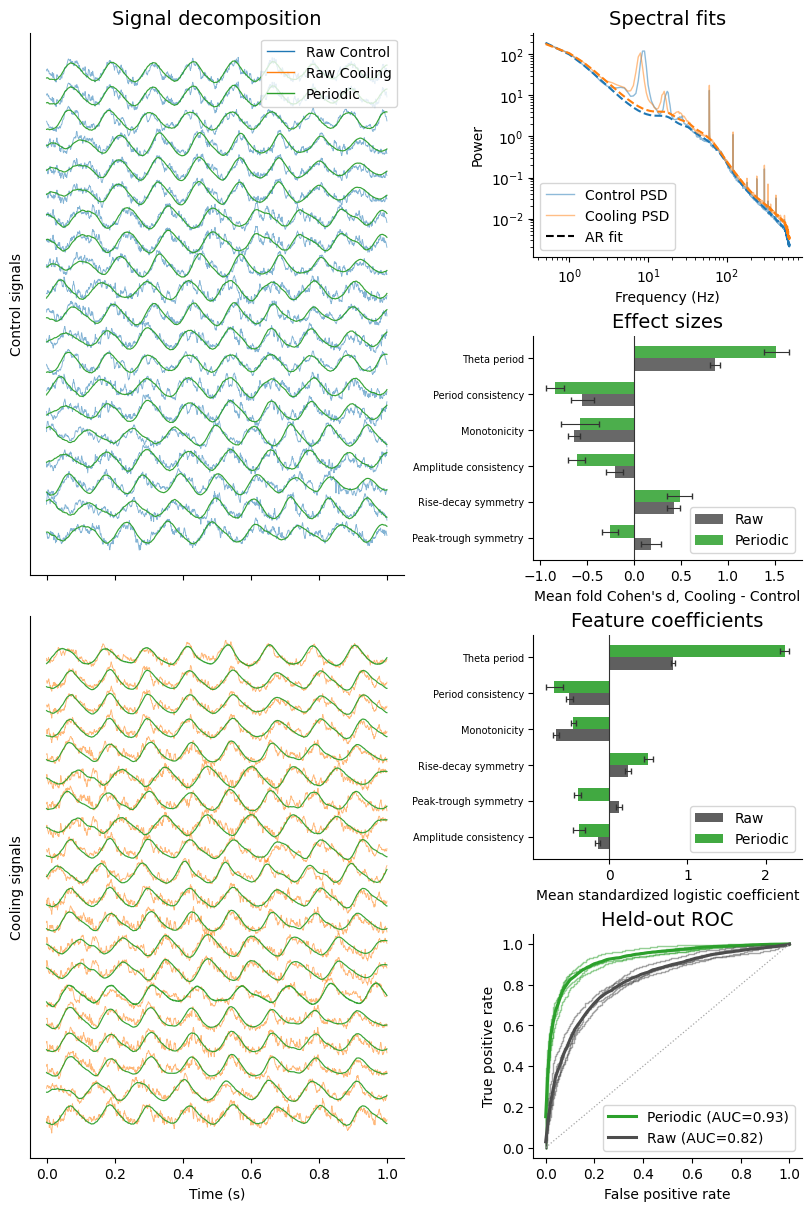

In [7]:
PUBLICATION_FIGURE_DIR = ROOT / "notebooks" / "figures"
PUBLICATION_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PUBLICATION_COLORS = {
    "control": "C0",
    "cooling": "C1",
    "raw": "#4D4D4D",
    "aperiodic": "C4",
    "periodic": "C2",
}
PUBLICATION_CONDITION_LABELS = {"control": "Control", "cooling": "Cooling"}
TITLE_SIZE = 14
LEGEND_SIZE = 10
TRACE_PANEL_KWARGS = dict(seconds=1.0, n_rows=20, trace_scale=0.45, spacing=1.75)


def rename(name):
    labels = {
        "period_ms": "Theta period",
        "time_rdsym": "Rise-decay symmetry",
        "time_ptsym": "Peak-trough symmetry",
        "volt_rise": "Rise voltage",
        "volt_decay": "Decay voltage",
        "band_amp": "Band amplitude",
        "monotonicity": "Monotonicity",
        "amp_fraction": "Amplitude fraction",
        "amp_consistency": "Amplitude consistency",
        "period_consistency": "Period consistency",
    }
    return labels.get(name, name.replace("_", " ").title())


def _finite(values):
    return pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)


def _cohen_d(control, cooling):
    control = _finite(control)
    cooling = _finite(cooling)
    if len(control) < 2 or len(cooling) < 2:
        return np.nan
    pooled = np.sqrt((control.var(ddof=1) + cooling.var(ddof=1)) / 2)
    return float((cooling.mean() - control.mean()) / (pooled + 1e-12))


def _summarize_fold_values(table, value):
    from scipy.stats import t as student_t

    summary = table.groupby(["label", "component"], as_index=False).agg(
        mean=(value, "mean"),
        sd=(value, "std"),
        n=(value, "count"),
    )
    summary["ci95"] = (
        student_t.ppf(0.975, summary["n"] - 1) * summary["sd"] / np.sqrt(summary["n"])
    ).where(summary["n"] > 1)
    return summary


def _plot_raw_periodic_trace_panel(fig, spec, *, seconds=1.0, n_rows=20, trace_scale=0.45, spacing=1.75):
    fold, decomp = next(iter(fold_decompositions.items()))
    rows = decomp["rows_test"]
    X_raw = notch_rows(X[rows["row"].to_numpy()], FS)
    X_periodic = notch_rows(decomp["X_periodic"], FS)
    sub = spec.subgridspec(len(CONDITIONS), 1, hspace=0.06)
    axes = []

    for i, condition in enumerate(CONDITIONS):
        ax = fig.add_subplot(sub[i, 0], sharex=axes[0] if axes else None)
        axes.append(ax)
        idx = np.flatnonzero(rows["condition"].eq(condition).to_numpy())
        scores = X_periodic[idx].std(axis=1) if len(idx) else np.array([])
        chosen = idx[np.argsort(scores)[-min(n_rows, len(idx)):]][::-1]
        n = min(X_raw.shape[1], int(round(seconds * FS)))
        t = np.arange(n) / FS
        yticks = []
        ylabels = []
        for j, row in enumerate(chosen):
            raw = X_raw[row, :n]
            periodic = X_periodic[row, :n]
            raw = (raw - raw.mean()) / (raw.std() + 1e-12)
            periodic = (periodic - periodic.mean()) / (periodic.std() + 1e-12)
            offset = (len(chosen) - 1 - j) * spacing
            ax.plot(t, offset + trace_scale * raw, color=PUBLICATION_COLORS[condition], lw=0.65, alpha=0.55)
            ax.plot(t, offset + trace_scale * periodic, color=PUBLICATION_COLORS["periodic"], lw=0.85, alpha=0.95)
            yticks.append(offset)
            ylabels.append(str(j))
        ax.set_yticks([])
        # ax.set_yticklabels(ylabels, fontsize=6)
        ax.set_ylabel(PUBLICATION_CONDITION_LABELS[condition] + " signals")
        ax.spines[["top", "right"]].set_visible(False)
        if i < len(CONDITIONS) - 1:
            ax.tick_params(labelbottom=False)
        else:
            ax.set_xlabel("Time (s)")

    axes[0].set_title("Signal decomposition", size=TITLE_SIZE)
    axes[0].legend(
        handles=[
            Line2D([0], [0], color=PUBLICATION_COLORS["control"], lw=1.0, label="Raw Control"),
            Line2D([0], [0], color=PUBLICATION_COLORS["cooling"], lw=1.0, label="Raw Cooling"),
            Line2D([0], [0], color=PUBLICATION_COLORS["periodic"], lw=1.0, label="Periodic"),
        ],
        fontsize=LEGEND_SIZE,
        loc="upper right",
    )


def _plot_spectrum_fit(ax):
    for condition in CONDITIONS:
        condition_keep = keep & split_labels["condition"].eq(condition).to_numpy()
        X_condition = X[condition_keep]

        psd_model = RobustAperiodicAR(
            fs=FS,
            order=AR_ORDER,
            fit_min_freq=AR_FIT_MIN_FREQ,
            fit_max_freq=AR_FIT_MAX_FREQ,
            loss_fn=AR_LOSS_FN,
            f_scale=AR_F_SCALE,
            maxfev=AR_MAXFEV,
            asymmetric_overfit_penalty=AR_ASYMMETRIC_OVERFIT_PENALTY,
            overfit_weight=AR_OVERFIT_WEIGHT,
            low_freq_residual_weight=AR_LOW_FREQ_RESIDUAL_WEIGHT,
            low_freq_overfit_weight=AR_LOW_FREQ_OVERFIT_WEIGHT,
            low_freq_max=AR_LOW_FREQ_MAX,
            loglog_slope_change_weight=AR_LOGLOG_SLOPE_CHANGE_WEIGHT,
            positive_loglog_slope_weight=AR_POSITIVE_LOGLOG_SLOPE_WEIGHT,
            positive_loglog_slope_tolerance=AR_POSITIVE_LOGLOG_SLOPE_TOLERANCE,
            slope_penalty_grid_size=AR_SLOPE_PENALTY_GRID_SIZE,
        )
        model = OscEig(
            fs=FS,
            psd_model=psd_model,
            periodic_mode=PERIODIC_MODE,
        )
        model.fit(X_condition)

        freqs = model.freqs_pos_
        powers = model.powers_pos_ / len(X_condition)
        fit = model.powers_fit_pos_ / len(X_condition)
        plot_keep = (freqs > 0) & np.isfinite(powers) & np.isfinite(fit) & (powers > 0) & (fit > 0)
        color = PUBLICATION_COLORS[condition]
        label = PUBLICATION_CONDITION_LABELS[condition]
        ax.loglog(freqs[plot_keep], powers[plot_keep], color=color, lw=1.0, alpha=0.5, label=f"{label} PSD")
        ax.loglog(freqs[plot_keep], fit[plot_keep], color=color, lw=1.5, alpha=1.0, ls="--")

    ax.set_title("Spectral fits", size=TITLE_SIZE)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power")
    handles, labels = ax.get_legend_handles_labels()
    handles.append(Line2D([0], [0], color="k", lw=1.5, ls="--"))
    labels.append("AR fit")
    ax.legend(handles, labels, fontsize=LEGEND_SIZE)
    ax.spines[["top", "right"]].set_visible(False)


def _plot_effect_sizes(ax, feature_columns):
    rows = cooling_row_features[cooling_row_features["split"].eq("test")].copy()
    effects = []
    for (fold, component), fold_rows in rows.groupby(["fold", "component"]):
        for feature in feature_columns:
            effect = _cohen_d(
                fold_rows.loc[fold_rows["condition"].eq("control"), feature],
                fold_rows.loc[fold_rows["condition"].eq("cooling"), feature],
            )
            if np.isfinite(effect):
                effects.append({"fold": fold, "label": rename(feature), "component": component, "effect": effect})
    summary = _summarize_fold_values(pd.DataFrame(effects), "effect")
    order = summary.groupby("label")["mean"].apply(lambda s: np.nanmax(np.abs(s))).sort_values().index.tolist()
    y_lookup = {label: i for i, label in enumerate(order)}
    width = 0.34
    for component, shift in [("raw", -width / 2), ("periodic", width / 2)]:
        component_rows = summary[summary["component"].eq(component)]
        ax.barh(
            [y_lookup[label] + shift for label in component_rows["label"]],
            component_rows["mean"],
            xerr=component_rows["ci95"],
            height=width,
            color=PUBLICATION_COLORS[component],
            alpha=0.85,
            label=component.title(),
            error_kw={"ecolor": "0.2", "elinewidth": 0.8, "capsize": 2},
        )
    ax.axvline(0, color="0.2", lw=0.8)
    ax.set_yticks(range(len(order)), order, fontsize=7)
    ax.set_xlabel("Mean fold Cohen's d, Cooling - Control")
    ax.set_title("Effect sizes", size=TITLE_SIZE)
    ax.legend(fontsize=LEGEND_SIZE)
    ax.spines[["top", "right"]].set_visible(False)


def _plot_roc(ax, scores):
    predictions = scores.attrs.get("oof_predictions", pd.DataFrame())
    grid = np.linspace(0, 1, 101)
    for component, rows in predictions.groupby("component"):
        color = PUBLICATION_COLORS[component]
        fold_curves = []
        for _, fold_rows in rows.groupby("fold"):
            fpr, tpr, _ = roc_curve(fold_rows["y_true"], fold_rows["y_score"])
            ax.plot(fpr, tpr, color=color, alpha=0.5, lw=1.0)
            fold_curves.append(np.interp(grid, fpr, tpr))
        mean_tpr = np.mean(fold_curves, axis=0)
        mean_auc = auc(grid, mean_tpr)
        ax.plot(grid, mean_tpr, color=color, lw=2.2, label=f"{component.title()} (AUC={mean_auc:.2f})")
    ax.plot([0, 1], [0, 1], color="0.65", lw=0.9, ls=":")
    ax.set_title("Held-out ROC", size=TITLE_SIZE)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.legend(fontsize=LEGEND_SIZE, loc="lower right")
    ax.spines[["top", "right"]].set_visible(False)


def _plot_coefficients(ax, coefficients, feature_columns):
    coef = coefficients[coefficients["feature"].isin(feature_columns)].copy()
    coef["label"] = coef["feature"].map(rename)
    summary = _summarize_fold_values(coef, "standardized_logistic_coef")
    order = summary.groupby("label")["mean"].apply(lambda s: np.nanmax(np.abs(s))).sort_values().index.tolist()
    y_lookup = {label: i for i, label in enumerate(order)}
    width = 0.34
    for component, shift in [("raw", -width / 2), ("periodic", width / 2)]:
        rows = summary[summary["component"].eq(component)]
        ax.barh(
            [y_lookup[label] + shift for label in rows["label"]],
            rows["mean"],
            xerr=rows["ci95"],
            height=width,
            color=PUBLICATION_COLORS[component],
            alpha=0.9,
            label=component.title(),
            error_kw={"ecolor": "0.2", "elinewidth": 0.8, "capsize": 2},
        )
    ax.axvline(0, color="0.2", lw=0.8)
    ax.set_yticks(range(len(order)), order, fontsize=7)
    ax.set_xlabel("Mean standardized logistic coefficient")
    ax.set_title("Feature coefficients", size=TITLE_SIZE)
    ax.legend(fontsize=LEGEND_SIZE)
    ax.spines[["top", "right"]].set_visible(False)


def make_publication_figure(variant_name, scores, coefficients, feature_columns):
    fig = plt.figure(figsize=(8, 12), constrained_layout=True)
    gs = fig.add_gridspec(8, 2, width_ratios=[0.6, 0.4])
    ax_spectral_fit = fig.add_subplot(gs[:2, 1])
    ax_effect_sizes = fig.add_subplot(gs[2:4, 1])
    ax_coefficients = fig.add_subplot(gs[4:6, 1])
    ax_roc = fig.add_subplot(gs[6:, 1])

    _plot_spectrum_fit(ax_spectral_fit)
    _plot_effect_sizes(ax_effect_sizes, feature_columns)
    _plot_coefficients(ax_coefficients, coefficients, feature_columns)
    _plot_roc(ax_roc, scores)
    _plot_raw_periodic_trace_panel(fig, gs[:, 0], **TRACE_PANEL_KWARGS)

    out = PUBLICATION_FIGURE_DIR / f"hippocampal_theta_{variant_name}.svg"
    fig.savefig(out, bbox_inches="tight")
    print(f"Saved {out}")
    return fig


fig_periodic_only = make_publication_figure(
    "periodic_only",
    publication_periodic_only_scores,
    publication_periodic_only_coefficients,
    THETA_PERIODIC_FEATURES,
)

plt.show()


In [8]:

AR_ORDER = 80
AR_FIT_MIN_FREQ = 1e-9
AR_FIT_MAX_FREQ = 550.0
AR_LOSS_FN = "linear"
AR_F_SCALE = None
AR_MAXFEV = 10_000

AR_ASYMMETRIC_OVERFIT_PENALTY = True
AR_OVERFIT_WEIGHT = 0.0
AR_LOW_FREQ_OVERFIT_WEIGHT = 0.0
AR_LOW_FREQ_RESIDUAL_WEIGHT = 500.0
AR_LOW_FREQ_MAX = 3.0

AR_LOGLOG_SLOPE_CHANGE_WEIGHT = 1.0
AR_POSITIVE_LOGLOG_SLOPE_WEIGHT = 100.0
AR_POSITIVE_LOGLOG_SLOPE_TOLERANCE = 0.0
AR_SLOPE_PENALTY_GRID_SIZE = 256

C = 1.0
LINE_FREQ = 60.0
LINE_NOTCH_Q = 30.0

In [9]:
PERIODIC_MODE

'quadrature_phase'

Maximum |raw - aperiodic - periodic| by condition: {'control': 1.7763568394002505e-15, 'cooling': 1.9984014443252818e-15}


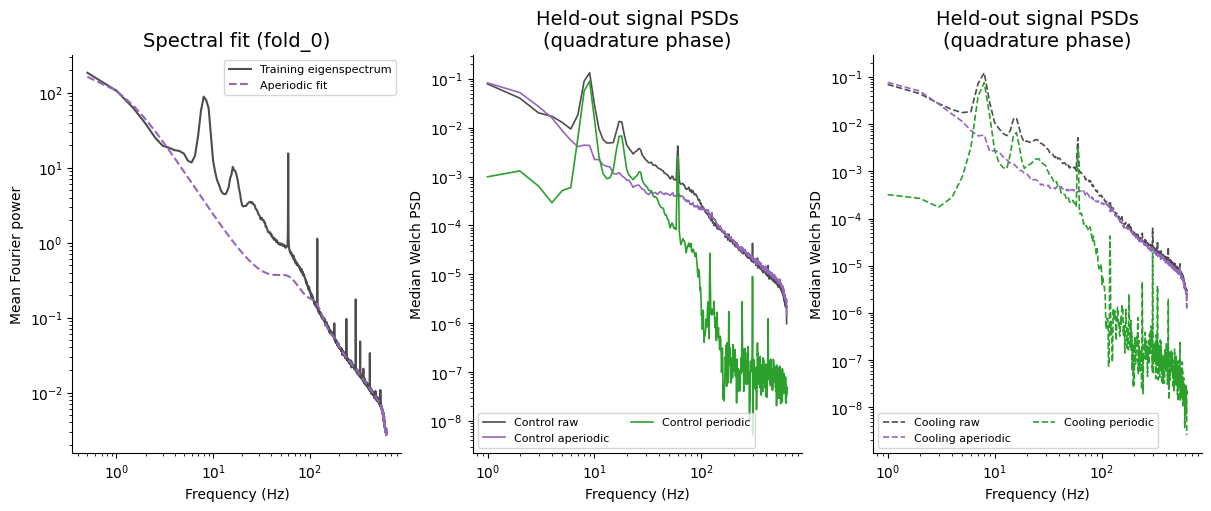

In [10]:
# End-to-end spectral-fit/decomposition experiment. No notch is applied.
EXPERIMENT_FOLD = split_columns[0]
EXPERIMENT_AR_ORDER = 20
EXPERIMENT_AR_FIT_MIN_FREQ = 1e-9
EXPERIMENT_AR_FIT_MAX_FREQ = 550.0
EXPERIMENT_AR_LOSS_FN = "linear"
EXPERIMENT_AR_F_SCALE = None
EXPERIMENT_AR_MAXFEV = 10_000

EXPERIMENT_AR_ASYMMETRIC_OVERFIT_PENALTY = True
EXPERIMENT_AR_OVERFIT_WEIGHT = 0.0
EXPERIMENT_AR_LOW_FREQ_OVERFIT_WEIGHT = 0.0
EXPERIMENT_AR_LOW_FREQ_RESIDUAL_WEIGHT = 500.0
EXPERIMENT_AR_LOW_FREQ_MAX = 3.0

EXPERIMENT_AR_LOGLOG_SLOPE_CHANGE_WEIGHT = 1.0
EXPERIMENT_AR_POSITIVE_LOGLOG_SLOPE_WEIGHT = 100.0
EXPERIMENT_AR_POSITIVE_LOGLOG_SLOPE_TOLERANCE = 0.0

EXPERIMENT_AR_SLOPE_PENALTY_GRID_SIZE = 256
EXPERIMENT_PSD_NPERSEG = int(FS)
# 'additive': legacy phase-preserving residual; signals sum exactly.
# 'quadrature': exact signal sum, smooth fitted aperiodic PSD, and
# positive-excess periodic PSD using the original fixed branch.
# 'quadrature_phase': exact signal sum and fitted aperiodic PSD, with raw
# phase preserved wherever the periodic amplitude residual is positive.
EXPERIMENT_PERIODIC_MODE = "quadrature_phase"
EXPERIMENT_PLOT_FREQUENCIES = (1.0, 40.0)
EXPERIMENT_COLORS = {"raw": "#4D4D4D", "aperiodic": "C4", "periodic": "C2"}
EXPERIMENT_CONDITION_LABELS = {"control": "Control", "cooling": "Cooling"}
EXPERIMENT_TITLE_SIZE = 14
EXPERIMENT_LEGEND_SIZE = 8


experiment_train_keep = keep & split_labels[EXPERIMENT_FOLD].eq("train").to_numpy()
experiment_test_keep = keep & split_labels[EXPERIMENT_FOLD].eq("test").to_numpy()
X_experiment_train = X[experiment_train_keep]
X_experiment_test = X[experiment_test_keep]
experiment_test_rows = split_labels.loc[experiment_test_keep].reset_index(drop=True)

experiment_psd_model = RobustAperiodicAR(
    fs=FS,
    order=EXPERIMENT_AR_ORDER,
    fit_min_freq=EXPERIMENT_AR_FIT_MIN_FREQ,
    fit_max_freq=EXPERIMENT_AR_FIT_MAX_FREQ,
    loss_fn=EXPERIMENT_AR_LOSS_FN,
    f_scale=EXPERIMENT_AR_F_SCALE,
    maxfev=EXPERIMENT_AR_MAXFEV,
    asymmetric_overfit_penalty=EXPERIMENT_AR_ASYMMETRIC_OVERFIT_PENALTY,
    overfit_weight=EXPERIMENT_AR_OVERFIT_WEIGHT,
    low_freq_residual_weight=EXPERIMENT_AR_LOW_FREQ_RESIDUAL_WEIGHT,
    low_freq_overfit_weight=EXPERIMENT_AR_LOW_FREQ_OVERFIT_WEIGHT,
    low_freq_max=EXPERIMENT_AR_LOW_FREQ_MAX,
    loglog_slope_change_weight=EXPERIMENT_AR_LOGLOG_SLOPE_CHANGE_WEIGHT,
    positive_loglog_slope_weight=EXPERIMENT_AR_POSITIVE_LOGLOG_SLOPE_WEIGHT,
    positive_loglog_slope_tolerance=EXPERIMENT_AR_POSITIVE_LOGLOG_SLOPE_TOLERANCE,
    slope_penalty_grid_size=EXPERIMENT_AR_SLOPE_PENALTY_GRID_SIZE,
)
experiment_model = OscEig(
    fs=FS,
    psd_model=experiment_psd_model,
    periodic_mode=EXPERIMENT_PERIODIC_MODE,
)
experiment_model.fit(X_experiment_train)

# Reconstruct each held-out condition against the smooth train-fitted AR
# eigenspectrum. Scaling by row count preserves the fitted per-row target
# power when held-out and training row counts differ.
# This is a plot-only, condition-aware reconstruction; do not use these
# components as inputs to the classifier.
from eigvec.core import reconstruct

X_experiment_aperiodic = np.empty_like(X_experiment_test)
X_experiment_periodic = np.empty_like(X_experiment_test)
experiment_reconstruction_error_by_condition = {}
for condition in CONDITIONS:
    condition_keep = experiment_test_rows["condition"].eq(condition).to_numpy()
    experiment_target_powers = (
        experiment_model.powers_fit_
        * int(condition_keep.sum())
        / len(X_experiment_train)
    )
    X_condition_aperiodic, X_condition_periodic, _, _, _ = reconstruct(
        X_experiment_test[condition_keep],
        experiment_target_powers,
        return_factors=False,
        periodic_mode=EXPERIMENT_PERIODIC_MODE,
    )
    X_experiment_aperiodic[condition_keep] = X_condition_aperiodic
    X_experiment_periodic[condition_keep] = X_condition_periodic
    experiment_reconstruction_error_by_condition[condition] = float(
        np.max(
            np.abs(
                X_experiment_test[condition_keep]
                - X_condition_aperiodic
                - X_condition_periodic
            )
        )
    )
print("Maximum |raw - aperiodic - periodic| by condition:", experiment_reconstruction_error_by_condition)

fig, (ax_fit, ax_decomposed0, ax_decomposed1) = plt.subplots(1, 3, figsize=(12, 5), constrained_layout=True)
ax_decomposed = [ax_decomposed0, ax_decomposed1]

fit_freqs = experiment_model.freqs_pos_
fit_raw = experiment_model.powers_pos_ / len(X_experiment_train)
fit_aperiodic = experiment_model.powers_fit_pos_ / len(X_experiment_train)
fit_keep = (fit_freqs > 0) & np.isfinite(fit_raw) & np.isfinite(fit_aperiodic) & (fit_raw > 0) & (fit_aperiodic > 0)
ax_fit.loglog(fit_freqs[fit_keep], fit_raw[fit_keep], color=EXPERIMENT_COLORS["raw"], label="Training eigenspectrum")
ax_fit.loglog(fit_freqs[fit_keep], fit_aperiodic[fit_keep], color=EXPERIMENT_COLORS["aperiodic"], ls="--", label="Aperiodic fit")

ax_fit.set_title(f"Spectral fit ({EXPERIMENT_FOLD})", size=EXPERIMENT_TITLE_SIZE)
ax_fit.set_xlabel("Frequency (Hz)")
ax_fit.set_ylabel("Mean Fourier power")
ax_fit.legend(fontsize=EXPERIMENT_LEGEND_SIZE)
ax_fit.spines[["top", "right"]].set_visible(False)

experiment_components = {
    "raw": X_experiment_test,
    "aperiodic": X_experiment_aperiodic,
    "periodic": X_experiment_periodic,
}
condition_styles = {"control": "-", "cooling": "--"}
for idx, condition in enumerate(CONDITIONS):
    condition_keep = experiment_test_rows["condition"].eq(condition).to_numpy()
    for component, X_component in experiment_components.items():
        freqs, powers = welch(
            X_component[condition_keep],
            fs=FS,
            nperseg=min(EXPERIMENT_PSD_NPERSEG, X_component.shape[1]),
            axis=1,
        )
        spectrum = np.nanmedian(powers, axis=0)
        plot_keep = (freqs > 0) & np.isfinite(spectrum) & (spectrum > 0)
        ax_decomposed[idx].loglog(
            freqs[plot_keep],
            spectrum[plot_keep],
            color=EXPERIMENT_COLORS[component],
            ls=condition_styles[condition],
            lw=1.2,
            label=f"{EXPERIMENT_CONDITION_LABELS[condition]} {component}",
        )

for ax in ax_decomposed:
    periodic_mode_label = EXPERIMENT_PERIODIC_MODE.replace("_", " ")
    ax.set_title(f"Held-out signal PSDs\n({periodic_mode_label})", size=EXPERIMENT_TITLE_SIZE)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Median Welch PSD")
    ax.legend(fontsize=EXPERIMENT_LEGEND_SIZE, ncol=2)
    ax.spines[["top", "right"]].set_visible(False)
plt.show()


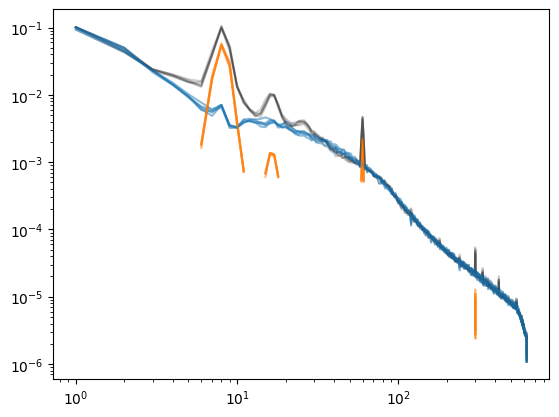

In [11]:
from neurodsp.spectral import compute_spectrum



eps = 1e-12

for idx in range(5):
    fold = 'fold_' + str(idx)
    f = np.median
    freqs, powers_periodic = compute_spectrum(fold_decompositions[fold]["X_periodic"], FS)
    freqs, powers_aperiodic = compute_spectrum(fold_decompositions[fold]["X_aperiodic"], FS)
    freqs, powers_raw = compute_spectrum(fold_decompositions[fold]["X_test"], FS)

    pr = f(powers_raw, axis=0)
    pap = f(powers_aperiodic, axis=0)[1:]
    ppe = f(powers_periodic, axis=0)[1:]

    m = ppe > (pap * 0.1)
    m[0] = False
    wherem = np.where(m)[0]
    splits = np.split(wherem, np.where(np.diff(wherem) != 1)[0]+1)

    plt.loglog(freqs[1:], pr[1:], color='k', alpha=0.2)

    plt.loglog(freqs[1:], pap, color='C0', alpha=0.5)

    for i in splits:
        plt.loglog(freqs[1:][i], ppe[i], color='C1', alpha=0.5)

    reconstructed_power = pap + ppe
    relative_excess = ppe / np.maximum(pap, eps)


    # plt.fill_between(
    #     freqs[1:],
    #     pap,
    #     reconstructed_power,
    #     where=relative_excess > 0.01,
    #     color="C1",
    #     alpha=0.15,
    # )
